In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [2]:
# Load the raw structural dataset
iris_raw = load_iris()

# Parse data into a clean structured Pandas DataFrame
df = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)
df['target'] = iris_raw.target

# Map categorical names back to numerical representations for inspection
df['species_name'] = df['target'].map({i: name for i, name in enumerate(iris_raw.target_names)})

print("====== DECODELABS ARTIFACT ASSESSMENT: RAW INPUT PROFILE ======")
print(f"Total Database Samples Observed: {df.shape[0]}")
print(f"Total Structural Dimensions Extracted: {df.shape[1] - 2}")
print("\nFirst 5 Structural Database Entries:")
print(df.head())

====== DECODELABS ARTIFACT ASSESSMENT: RAW INPUT PROFILE ======
Total Database Samples Observed: 150
Total Structural Dimensions Extracted: 4

First 5 Structural Database Entries:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species_name  
0       0       setosa  
1       0       setosa  
2       0       setosa  
3       0       setosa  
4       0       setosa  


In [3]:
# =====================================================================
# STEP 2: PROCESS LAYER - FEATURE SCALING
# =====================================================================
# Isolate input features (X) and target dependency labels (y)
X = df[iris_raw.feature_names]
y = df['target']

# Initialize the scaling gatekeeper matrix
scaler = StandardScaler()

# Transform features to reach Mean = 0, Variance = 1
X_scaled = scaler.fit_transform(X)

print("====== DECODELABS MATRIX TRANSFORMATION VERIFIED ======")
print(f"Raw Input Metrics Row 1: {X.iloc[0].values}")
print(f"Standard Scaled Matrix Row 1: {X_scaled[0]}")

====== DECODELABS MATRIX TRANSFORMATION VERIFIED ======
Raw Input Metrics Row 1: [5.1 3.5 1.4 0.2]
Standard Scaled Matrix Row 1: [-0.90068117  1.01900435 -1.34022653 -1.3154443 ]


In [9]:
# =====================================================================
# STEP 3: PROCESS LAYER - DATA SHUFFLE & STRUCTURAL PARTITION
# =====================================================================
# Stratify keeps class distributions perfectly identical across pools
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.20, 
    random_state=42, 
    shuffle=True, 
    stratify=y
)

print("====== PARTITION ARCHITECTURE DEPLOYED ======")
print(f"Training Array Distribution (80% Matrix): {X_train.shape[0]} tracking samples")
print(f"Testing Validation Vector (20% Matrix): {X_test.shape[0]} unseen samples")

====== PARTITION ARCHITECTURE DEPLOYED ======
Training Array Distribution (80% Matrix): 120 tracking samples
Testing Validation Vector (20% Matrix): 30 unseen samples


In [5]:

# Deploying KNN Classifier with localized neighborhood metrics (K=3)
knn_engine = KNeighborsClassifier(n_neighbors=3)

# Pass history through the algorithm to extract logic patterns natively
knn_engine.fit(X_train, y_train)

# Feed validation pool across the derived logic thresholds
y_predictions = knn_engine.predict(X_test)

print("====== SYSTEM ALERTER: ALGORITHMIC PIPELINE COMPLETION ======")
print("Supervised learning execution complete. No manual rules injected.")

====== SYSTEM ALERTER: ALGORITHMIC PIPELINE COMPLETION ======
Supervised learning execution complete. No manual rules injected.


            DECODELABS INDUSTRIAL TRAINING COMPLIANCE LOG      
Engine Test Accuracy  : 93.33%
Weighted F1-Score Metric: 0.9327
---------------------------------------------------------------

Confusion Matrix Mapping Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Complete Analytical Structural Classification Manual Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



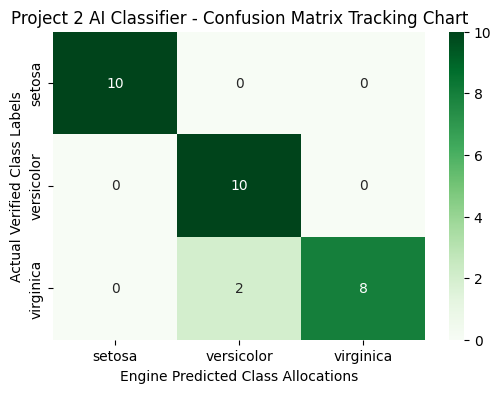

In [8]:
# =====================================================================
# STEP 5: OUTPUT LAYER - PERFORMANCE EVALUATION MATRIX
# =====================================================================
# Extract diagnostic metric scores
system_accuracy = accuracy_score(y_test, y_predictions)
system_f1 = f1_score(y_test, y_predictions, average='weighted')
conf_matrix = confusion_matrix(y_test, y_predictions)

print("===============================================================")
print("            DECODELABS INDUSTRIAL TRAINING COMPLIANCE LOG      ")
print("===============================================================")
print(f"Engine Test Accuracy  : {system_accuracy * 100:.2f}%")
print(f"Weighted F1-Score Metric: {system_f1:.4f}")
print("---------------------------------------------------------------")
print("\nConfusion Matrix Mapping Matrix:")
print(conf_matrix)
print("\nComplete Analytical Structural Classification Manual Report:")
print(classification_report(y_test, y_predictions, target_names=iris_raw.target_names))

# Create a clear visual evaluation chart
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris_raw.target_names, yticklabels=iris_raw.target_names)
plt.title('Project 2 AI Classifier - Confusion Matrix Tracking Chart')
plt.ylabel('Actual Verified Class Labels')
plt.xlabel('Engine Predicted Class Allocations')
plt.show()